In [1]:
# ============================================
# Comparación de extracción de features
# MobileNetV2 vs VGG16 vs ResNet50
# ============================================


In [2]:
ColabNotebook = 'google.colab' in str(get_ipython())

if ColabNotebook:
    # monta G-drive en entorno COLAB
    from google.colab import drive
    drive.mount('/content/drive/')

    DATOS_DIR = '/content/drive/MyDrive/Colab Notebooks/DATOS/'      # carpeta donde se encuentran los datasets
else:
    DATOS_DIR   = '../Datos/' # carpeta donde se encuentran los datasets


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalAveragePooling2D
import matplotlib.pyplot as plt

import os


In [4]:
# ----------------------------------------------------------
# 1. Cargar una imagen de ejemplo (puede ser cualquier JPG)
# ----------------------------------------------------------
# url = "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg"

# Ruta a la imagen local
url = "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg"
img_path = os.path.join(DATOS_DIR, "dog.jpg")



In [5]:
# ----------------------------------------------------------
# 2. Función para preprocesar según cada modelo
# ----------------------------------------------------------
def prepare_image(img_path, target_size, preprocess_fn):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_fn(x)
    return x, img


In [6]:
# ----------------------------------------------------------
# 3. MobileNetV2
# ----------------------------------------------------------
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
mobilenet_model.trainable = False
img_mob, img_disp = prepare_image(img_path, (96, 96), preprocess_mobilenet)
features_mob = mobilenet_model.predict(img_mob)
features_mob = GlobalAveragePooling2D()(features_mob).numpy()
print("MobileNetV2 - shape de salida:", features_mob.shape)

1/1 [==============================] - 1s 925ms/step
MobileNetV2 - shape de salida: (1, 1280)


In [7]:
# ----------------------------------------------------------
# 4. VGG16
# ----------------------------------------------------------
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_model.trainable = False
img_vgg, _ = prepare_image(img_path, (224, 224), preprocess_vgg)
features_vgg = vgg_model.predict(img_vgg)
features_vgg = GlobalAveragePooling2D()(features_vgg).numpy()
print("VGG16 - shape de salida:", features_vgg.shape)


1/1 [==============================] - 0s 289ms/step
VGG16 - shape de salida: (1, 512)


In [8]:
# ----------------------------------------------------------
# 5. ResNet50
# ----------------------------------------------------------
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_model.trainable = False
img_res, _ = prepare_image(img_path, (224, 224), preprocess_resnet)
features_res = resnet_model.predict(img_res)
features_res = GlobalAveragePooling2D()(features_res).numpy()
print("ResNet50 - shape de salida:", features_res.shape)


1/1 [==============================] - 1s 1s/step
ResNet50 - shape de salida: (1, 2048)


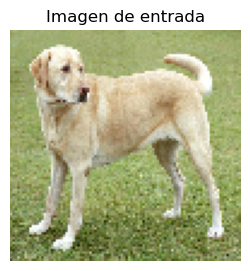


=== Resumen comparativo ===
MobileNetV2 → tamaño entrada (96x96), vector de features: (1, 1280)
VGG16       → tamaño entrada (224x224), vector de features: (1, 512)
ResNet50    → tamaño entrada (224x224), vector de features: (1, 2048)


In [9]:
# ----------------------------------------------------------
# 6. Mostrar imagen y resumen comparativo
# ----------------------------------------------------------
plt.figure(figsize=(3, 3))  # ancho, alto en pulgadas
plt.imshow(img_disp)
plt.axis('off')
plt.title("Imagen de entrada")
plt.show()

print("\n=== Resumen comparativo ===")
print("MobileNetV2 → tamaño entrada (96x96), vector de features:", features_mob.shape)
print("VGG16       → tamaño entrada (224x224), vector de features:", features_vgg.shape)
print("ResNet50    → tamaño entrada (224x224), vector de features:", features_res.shape)